# 02 · Bike-Sharing — Time-Series Foundations (multi-seasonal)

## Part 2 — Time-Series Foundations (multi-seasonal demand)

The S&P series had one weak seasonal cycle. Bike demand is the opposite: a strong **trend** plus
**multiple seasonalities** layered on top —

- **daily** (period 24h): the commute rhythm,
- **weekly** (period 168h): workweek vs weekend,
- **yearly**: warm-season peak.

That changes the toolkit: we need a regular hourly index, **MSTL** (multi-seasonal decomposition,
not single STL), and seasonal differencing aware of more than one period.

In [1]:
import sys, pathlib, warnings
warnings.filterwarnings("ignore", category=FutureWarning)
ROOT = pathlib.Path.cwd(); ROOT = ROOT if (ROOT / "src").exists() else ROOT.parent
sys.path.insert(0, str(ROOT))
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src import data, eda
eda.set_style()
pd.set_option("display.width", 120, "display.max_columns", 30)
print("setup ok | numpy", np.__version__, "| pandas", pd.__version__)

from statsmodels.tsa.seasonal import STL, MSTL
from src import ts
cnt = data.hourly_cnt()      # gapless hourly grid (165 gaps interpolated)
print("series:", len(cnt), "hours |", cnt.index.min(), "->", cnt.index.max(), "| freq", cnt.index.freq)

setup ok | numpy 2.1.3 | pandas 2.3.3


series: 17544 hours | 2011-01-01 00:00:00 -> 2012-12-31 23:00:00 | freq <Hour>


### 1. Index hygiene — fill the gaps first

Part 0 found **165 missing hours** in the 2-year grid. Lags and seasonal periods assume a *regular*
index, so before any modelling we reindex onto a complete hourly grid and **time-interpolate** the
holes (`data.hourly_cnt()` does this). A silent gap would otherwise misalign every lag-24/lag-168.

In [2]:
raw = data.clean()["cnt"]
print("raw hours:", len(raw), "| on a gapless grid:", len(cnt), "| interpolated:", len(cnt)-len(raw))

raw hours: 17379 | on a gapless grid: 17544 | interpolated: 165


### 2. Look first — trend, and a weekly/daily pattern on zoom

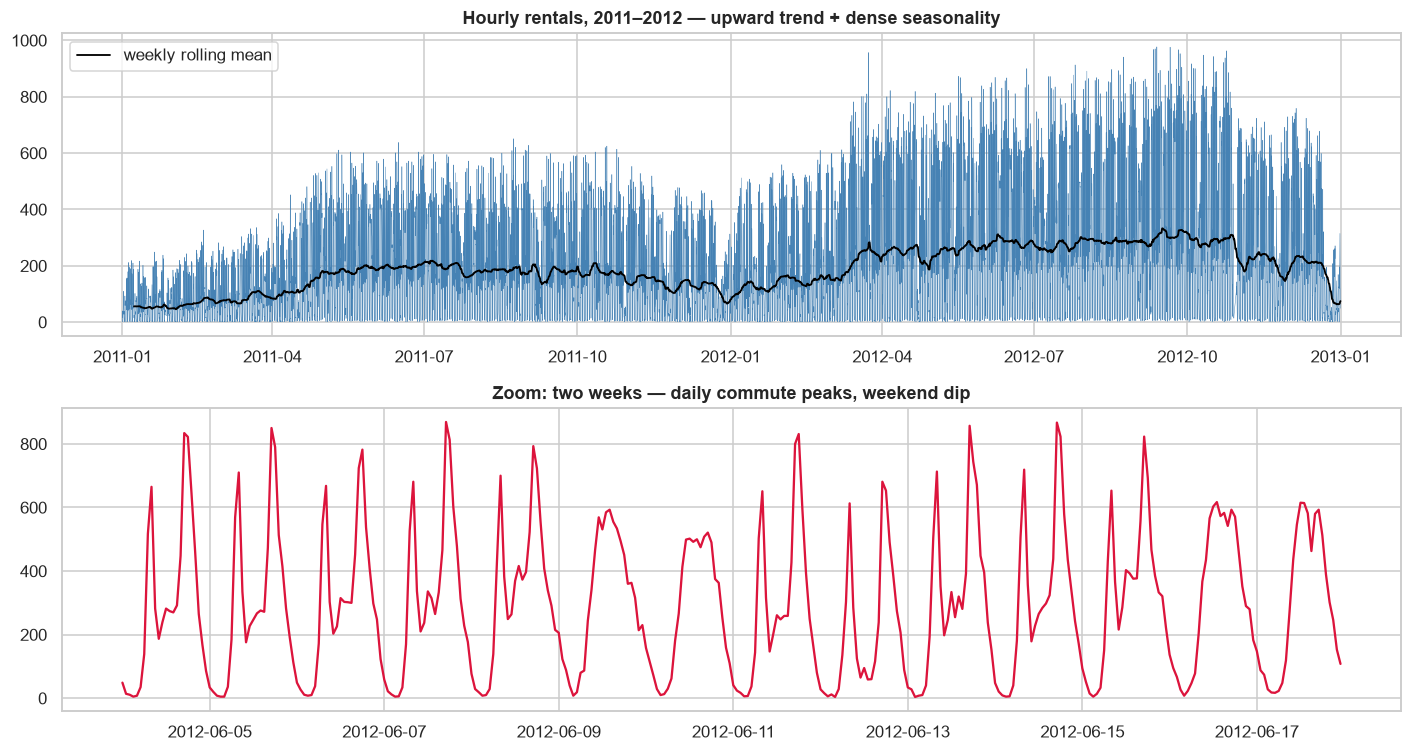

In [3]:
fig, ax = plt.subplots(2, 1, figsize=(13, 7))
ax[0].plot(cnt.index, cnt.values, lw=0.3, color="steelblue")
ax[0].plot(cnt.index, cnt.rolling(168).mean(), color="black", lw=1.2, label="weekly rolling mean")
ax[0].set_title("Hourly rentals, 2011–2012 — upward trend + dense seasonality"); ax[0].legend()
wk = cnt.loc["2012-06-04":"2012-06-17"]   # two summer weeks
ax[1].plot(wk.index, wk.values, color="crimson"); ax[1].set_title("Zoom: two weeks — daily commute peaks, weekend dip")
fig.tight_layout(); eda.savefig(fig, "p2_series.png"); plt.show()

### 3. The seasonal signatures + autocorrelation

The daily and weekly cycles show up directly as profiles, and as **ACF spikes at lags 24 and
168** — strong, slowly-decaying autocorrelation is the multi-seasonal memory a model must capture.

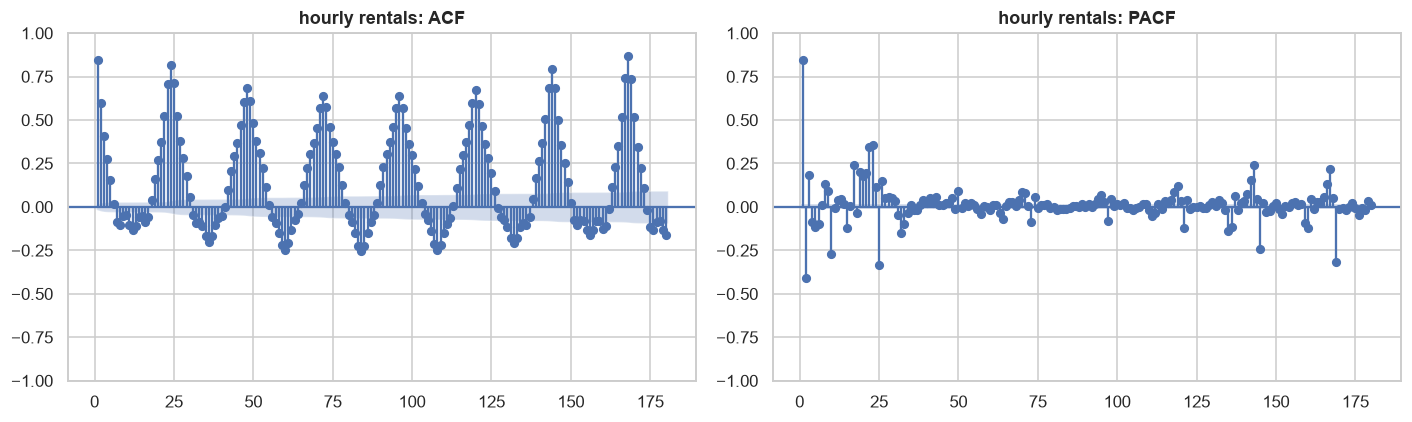

ACF: lag1=0.85  lag24=0.82 (daily)  lag168=0.87 (weekly)


In [4]:
fig = ts.acf_pacf_plot(cnt, lags=180, name="hourly rentals", fname="p2_acf.png"); plt.show()
from statsmodels.tsa.stattools import acf
a = acf(cnt, nlags=180)
print("ACF: lag1=%.2f  lag24=%.2f (daily)  lag168=%.2f (weekly)" % (a[1], a[24], a[168]))

### 4. MSTL — decomposing *multiple* seasonalities

Classical/STL decomposition handles **one** period. **MSTL** peels off several in turn — here daily
(24) and weekly (168) — leaving trend + each seasonal component + residual. The amplitudes rank the
drivers: the **daily** commute cycle is the biggest swing, then the **weekly** pattern, then the
slow growth **trend**.

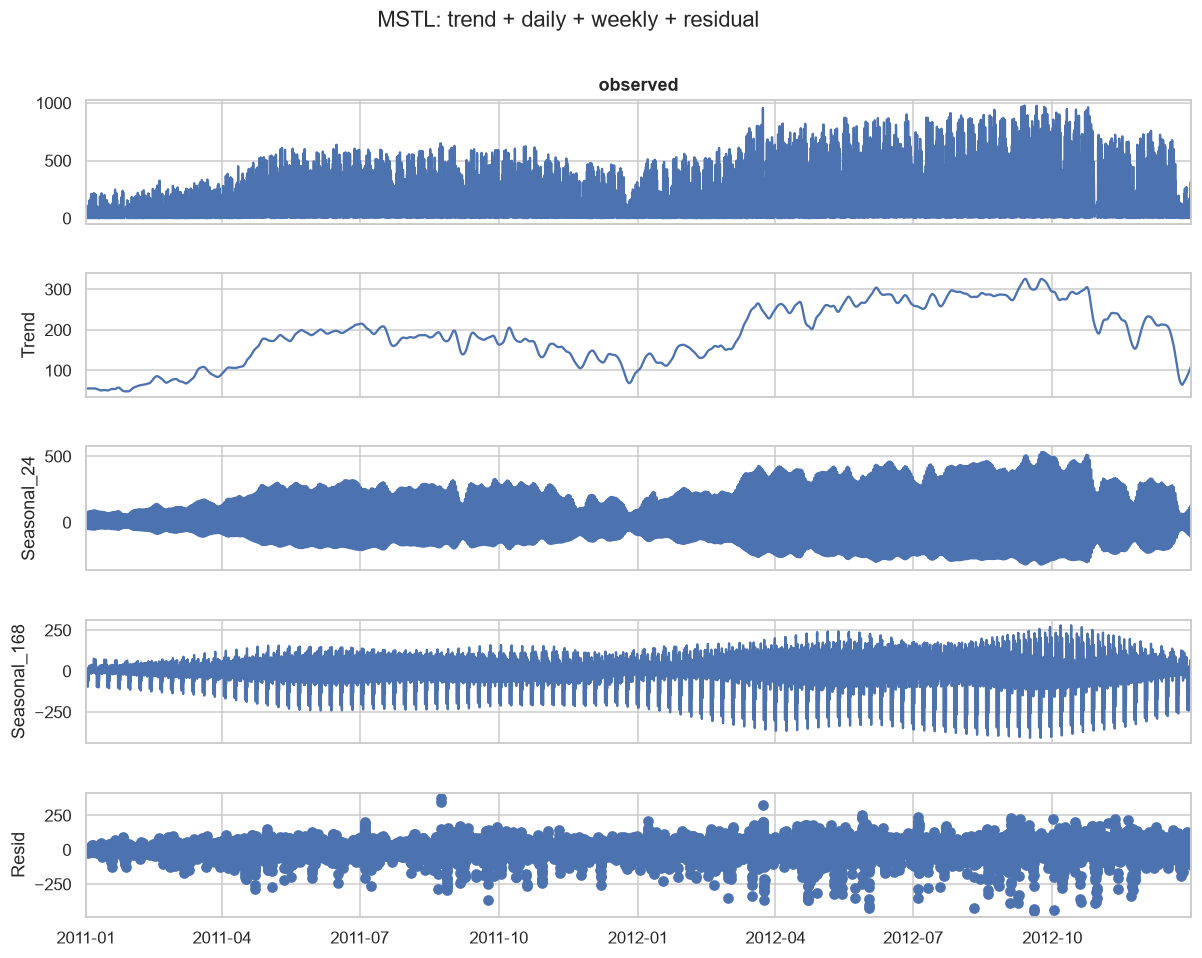

swing  daily=851  weekly=688  trend=277  (daily commute dominates)


In [5]:
res = MSTL(cnt, periods=(24, 168)).fit()
fig = res.plot(); fig.set_size_inches(12, 9); fig.suptitle("MSTL: trend + daily + weekly + residual", y=1.01)
eda.savefig(fig, "p2_mstl.png"); plt.show()
amp = lambda s: s.max()-s.min()
print("swing  daily=%.0f  weekly=%.0f  trend=%.0f  (daily commute dominates)"
      % (amp(res.seasonal['seasonal_24']), amp(res.seasonal['seasonal_168']), amp(res.trend)))

### 5. Stationarity — deseasonalize, then it's stationary

The raw series carries trend + seasonality, so it's non-stationary. Strip them with MSTL and the
**residual is stationary** (both ADF and KPSS agree) — the clean target a model's noise term should
look like.

In [6]:
for name, s in [("raw cnt", cnt), ("MSTL residual", res.resid), ("seasonal diff (lag 24)", cnt.diff(24).dropna())]:
    table, verdict = ts.stationarity_report(s, name=name)
    print(f"{name:22s} -> {verdict}")

raw cnt                -> DIFFERENCE-STATIONARY -> difference


MSTL residual          -> STATIONARY


seasonal diff (lag 24) -> STATIONARY


### 6. Did MSTL capture the structure? — residual ACF

If the decomposition worked, the residual should be close to white noise: the giant ACF spikes at
24 and 168 should largely collapse.

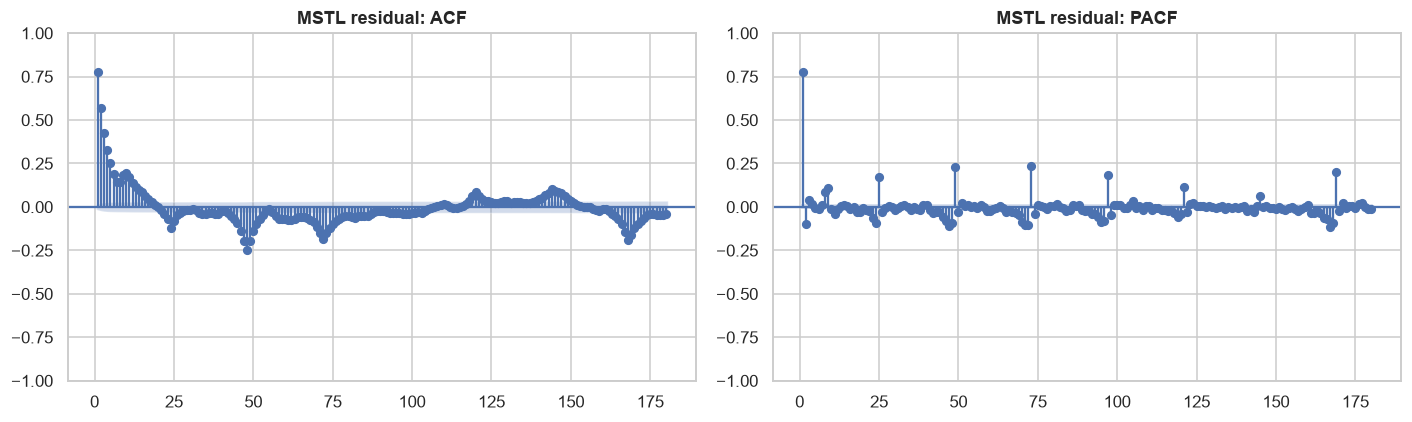

residual ACF: lag24 0.82 -> -0.12 , lag168 0.87 -> -0.19  (seasonality removed)


In [7]:
fig = ts.acf_pacf_plot(res.resid.dropna(), lags=180, name="MSTL residual", fname="p2_resid_acf.png"); plt.show()
ar = acf(res.resid.dropna(), nlags=180)
print("residual ACF: lag24 %.2f -> %.2f , lag168 %.2f -> %.2f  (seasonality removed)"
      % (a[24], ar[24], a[168], ar[168]))

### 7. Differencing — and why multi-seasonal is harder

Seasonal **differencing** at lag 24 removes the daily cycle and reaches stationarity. But with
*two* seasonal periods you'd need to difference at 24 **and** 168 (risking **over-differencing**),
which is clumsy — so in practice multi-seasonal series are handled by **MSTL**, **Fourier terms**,
or **ML models with calendar features** (Part 3) rather than stacked seasonal differences.

In [8]:
from statsmodels.tsa.stattools import acf as _acf
d1 = cnt.diff(24).dropna()
print("var cnt = %.0f | var diff24 = %.0f" % (cnt.var(), d1.var()))
print("lag-24 ACF: cnt %.2f -> diff24 %.2f  (daily cycle largely gone)" % (a[24], _acf(d1, nlags=24)[24]))

var cnt = 32862 | var diff24 = 11851
lag-24 ACF: cnt 0.82 -> diff24 -0.13  (daily cycle largely gone)


### Takeaways

- **Index hygiene at hourly scale**: 165 gaps were interpolated onto a regular grid before anything else.
- Demand is **multi-seasonal** — daily (24) and weekly (168) cycles show as **ACF spikes** and as
  distinct **MSTL** components; the daily commute cycle is the largest driver.
- The raw series is non-stationary; the **MSTL residual is stationary**, and its ACF is nearly flat
  → the decomposition captured the structure.
- Multiple seasonalities make stacked **seasonal differencing** awkward → prefer MSTL / Fourier /
  calendar-feature ML.

**Next — Part 3 (Forecasting with covariates):** predict `cnt` using the **weather + calendar**
drivers — SARIMAX with exogenous regressors, and a LightGBM model with lag + calendar features —
the payoff of having exogenous information the financial series never had.